# Customer Shopping Trends Exploratory Data Analysis

**Dataset:** [Customer Shopping Trends](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset) — 3,900 retail transactions covering customer demographics, purchase details, and shopping behavior.

**Goal:** To explore the dataset to understand who is buying, what they're buying, how much they're spending, and what patterns show up across categories, seasons, payment methods, and customer segments.

## 1. Setup & Data Loading

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Load the dataset

data = pd.read_csv("shopping_trends.csv")
data.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. Data Overview

Before diving into any analysis, I'm understanding the shape of the data: how many rows/columns we have, what types each column is, and a quick statistical summary of the numeric fields.

In [4]:
# Shape of the dataset
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 3900, Columns: 18


In [5]:
# Getting general information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

The dataset has 19 columns covering customer demographics (Age, Gender), purchase details (Item Purchased, Category, Purchase Amount, Size, Color, Season), and behavioral fields (Review Rating, Subscription Status, Payment Method, Frequency of Purchases).

In [6]:
# Summary statistics for numeric columns
data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


**Quick read:** the average purchase is around \$60, review ratings cluster tightly between roughly 2.5–5 (Review Rating is discrete to 1 decimal), and customers report between 1 and 50 previous purchases, so the base is a mix of new and highly repeat customers.

## 3. Data Quality Checks

Checking for missing values and duplicate rows before trusting any downstream aggregation.

In [6]:
# Checking for null values
data.isna().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [7]:
# Checking for duplicates
data.duplicated().sum()

np.int64(0)

**No missing values and no duplicate rows.** This dataset is already clean, so no imputation or de-duplication is needed before analysis.

## 4. Univariate Analysis

Looking at each variable of interest on its own to understand its distribution before comparing variables against each other.

### 4.1 Age Distribution

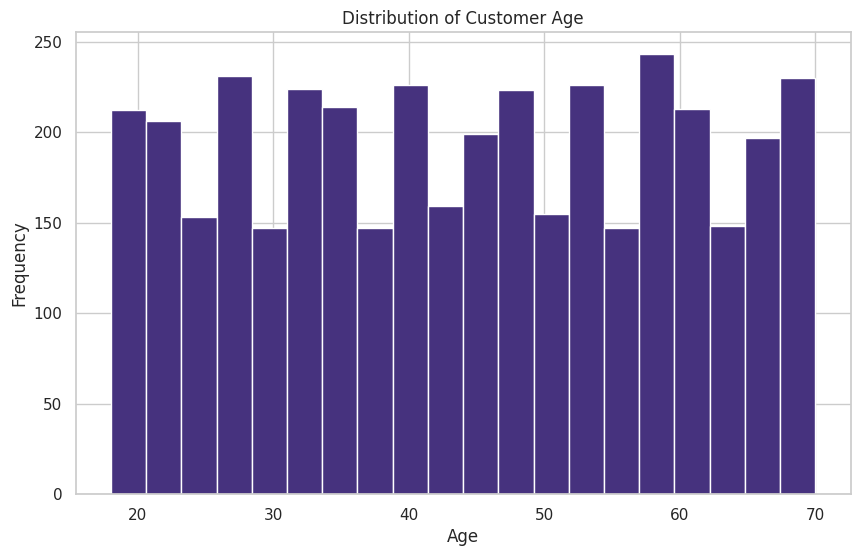

In [8]:
data["Age"].plot(kind="hist", bins=20, edgecolor="white")
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Customer age is fairly evenly spread from the high teens through the 60s, with no single age group dominating. This is a broad-based customer population rather than one skewed toward a particular generation.

### 4.2 Gender Distribution

In [9]:
data.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='str')

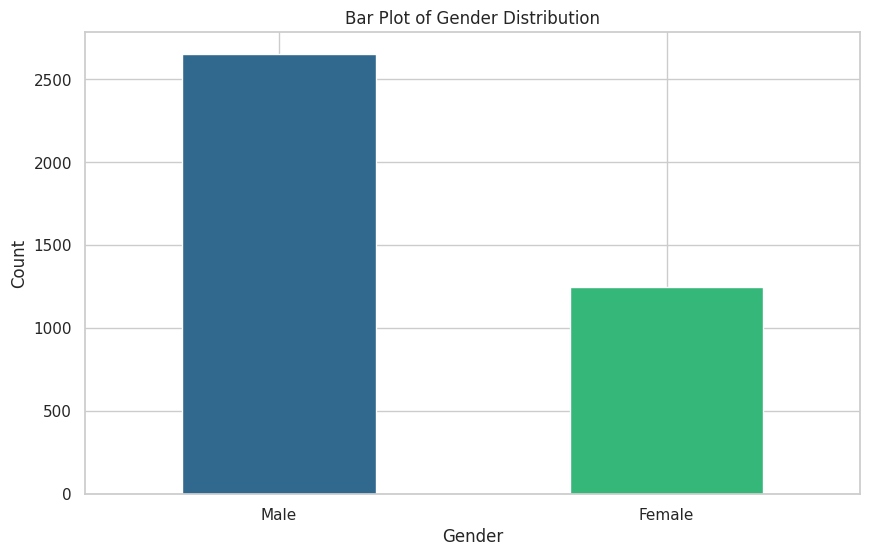

In [10]:
# Bar plot for gender distribution
data["Gender"].value_counts().plot(kind="bar", color=sns.color_palette("viridis", 2))
plt.title("Bar Plot of Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Male customers make up the clear majority of transactions in this dataset, roughly two-thirds of all purchases, with female customers making up the remainder.

### 4.3 Purchase Category Distribution

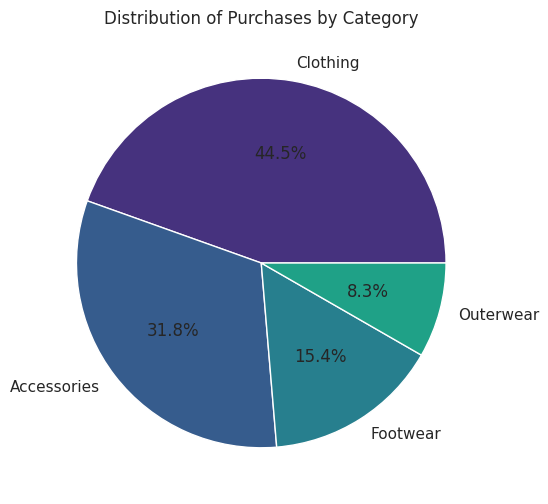

In [11]:
# Pie chart for category distribution
data["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%", ylabel="")
plt.title("Distribution of Purchases by Category")
plt.show()

Clothing is by far the most-purchased category, followed by Accessories, Footwear, and Outerwear — Outerwear makes up the smallest share, which makes sense as a more seasonal/occasional purchase.

### 4.4 Seasonal Distribution of Purchases

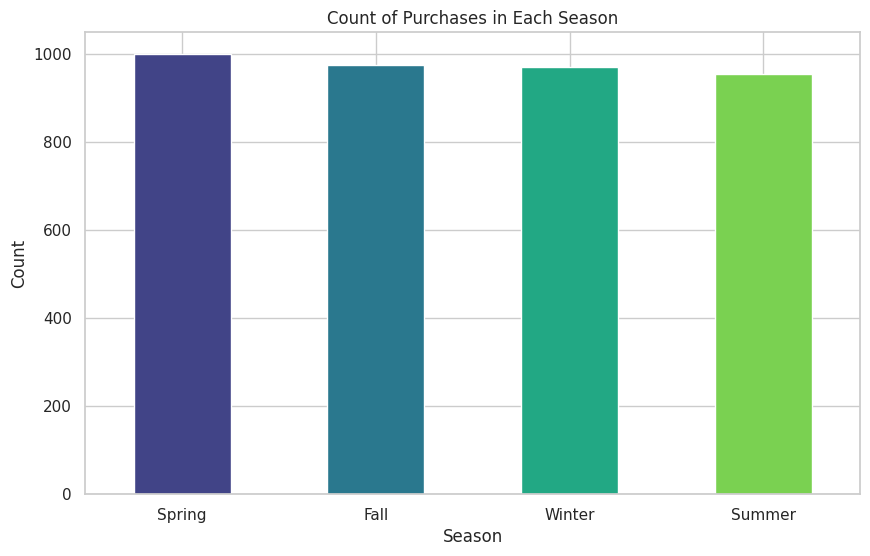

In [12]:
data["Season"].value_counts().plot(kind="bar", color=sns.color_palette("viridis", 4))
plt.xlabel("Season")
plt.ylabel("Count")
plt.title("Count of Purchases in Each Season")
plt.xticks(rotation=0)
plt.show()

Purchase volume is close to evenly split across all four seasons, so there isn't a single dominant shopping season in this dataset. The demand looks fairly stable all year round.

### 4.5 Purchase Amount Distribution

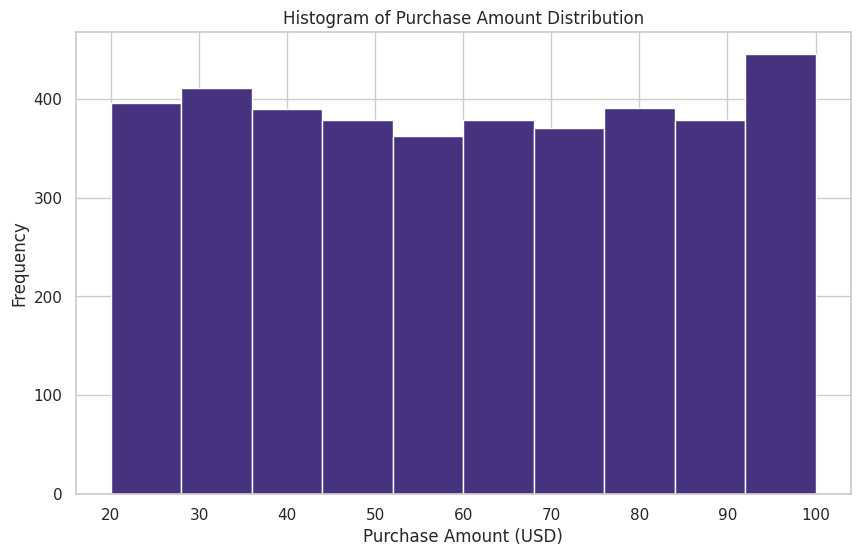

In [13]:
data["Purchase Amount (USD)"].plot(kind="hist", bins=10, edgecolor="white")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Purchase Amount Distribution")
plt.show()

Purchase amounts are roughly uniformly distributed between \$20 and \$100 rather than following a typical right-skewed spending pattern. There's no strong concentration around a 'typical' basket size.

### 4.6 Subscription Status

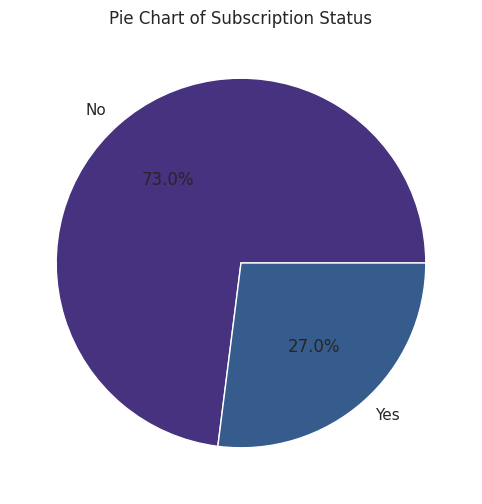

In [14]:
data["Subscription Status"].value_counts().plot(kind="pie", autopct="%1.1f%%", ylabel="")
plt.title("Pie Chart of Subscription Status")
plt.show()

Only about a quarter of customers are subscribers, meaning most of this customer base is transactional rather than locked into a recurring relationship. There's a potential opportunity for retention-focused offers.

### 4.7 Most Common Colors Purchased

In [15]:
data["Color"].value_counts().head()

Color
Olive     177
Yellow    174
Silver    173
Teal      172
Green     169
Name: count, dtype: int64

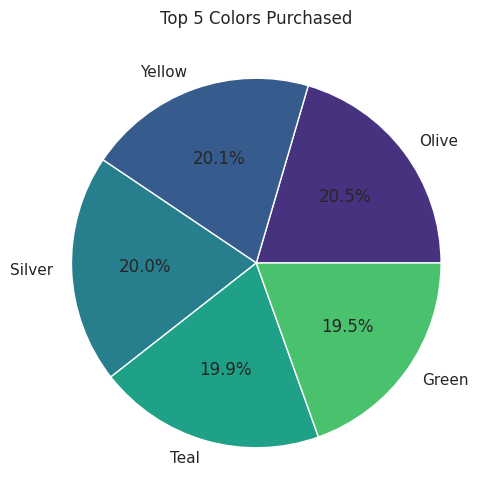

In [16]:
data["Color"].value_counts().head().plot(kind="pie", autopct="%1.1f%%", ylabel="")
plt.title("Top 5 Colors Purchased")
plt.show()

Among the top colors, preferences are fairly balanced with no single color dominating. Olive, Yellow, Silver, Teal, and Green are all purchased at similar rates.

## 5. Bivariate Analysis

Now we look at relationships between pairs of variables to see how spending, ratings, and behavior differ across customer and product segments.

### 5.1 Average Purchase Amount by Category

In [17]:
data.groupby("Category")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

Category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

Average spend is very close across all four categories (all within a couple of dollars of each other), so category alone isn't a strong driver of basket size in this dataset.

### 5.2 Previous Purchases vs. Review Rating

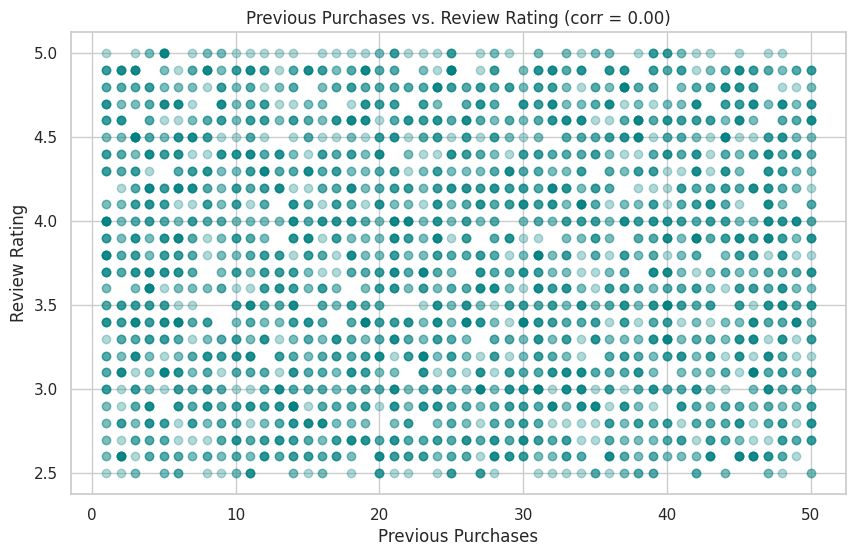

In [18]:
corr = data["Previous Purchases"].corr(data["Review Rating"])

plt.scatter(data["Previous Purchases"], data["Review Rating"], alpha=0.3, color="teal")
plt.title(f"Previous Purchases vs. Review Rating (corr = {corr:.2f})")
plt.xlabel("Previous Purchases")
plt.ylabel("Review Rating")
plt.show()

There is essentially no linear relationship between how many times a customer has purchased before and the rating they leave. A highly loyal repeat customer is no more or less likely to leave a high review than a first-time buyer.

### 5.3 Total Purchase Amount by Season

In [19]:
data.groupby("Season")["Purchase Amount (USD)"].sum()

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

### 5.4 Purchase Amount by Frequency of Purchases

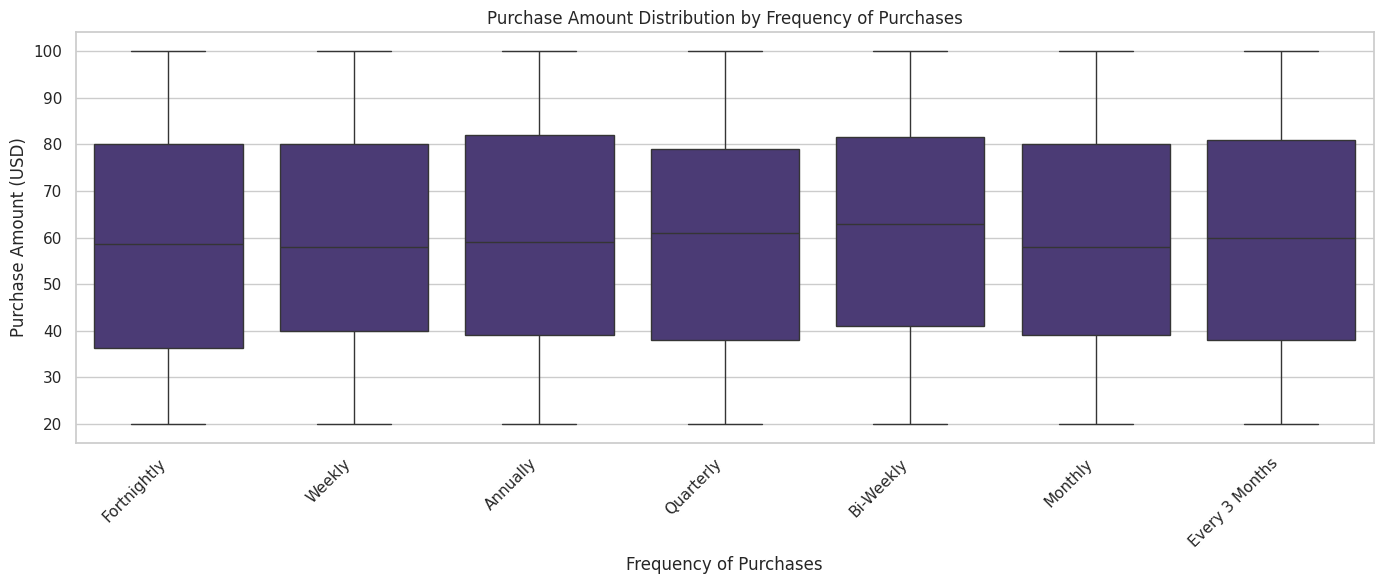

In [20]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=data, x="Frequency of Purchases", y="Purchase Amount (USD)")
plt.title("Purchase Amount Distribution by Frequency of Purchases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Median purchase amount is essentially flat across every purchase frequency bucket (weekly through annually) and how often someone shops doesn't correlate with how much they spend per transaction.

### 5.5 Most Common Payment Method

In [21]:
data["Payment Method"].value_counts().sort_values(ascending=False)

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64

Payment method usage is well-distributed across PayPal, Credit Card, Cash, Debit Card, Venmo, and Bank Transfer, without any single method dominating checkout.

### 5.6 Average Purchase Amount by Location and Item

In [22]:
pd.pivot_table(data, values="Purchase Amount (USD)", index="Location", columns="Item Purchased", aggfunc="mean").head()

Item Purchased,Backpack,Belt,Blouse,Boots,Coat,Dress,Gloves,Handbag,Hat,Hoodie,...,Scarf,Shirt,Shoes,Shorts,Skirt,Sneakers,Socks,Sunglasses,Sweater,T-shirt
Location,,,,,,,,,,,,,,,,,,,,,
Alabama,74.0,26.500000,52.0,73.666667,54.500000,55.200000,85.000000,57.666667,76.000000,53.000000,...,75.333333,48.2,54.333333,49.000000,68.666667,79.500000,93.50,62.666667,40.500000,52.50
Alaska,74.6,76.750000,67.5,56.000000,45.500000,74.500000,66.333333,46.000000,52.666667,56.500000,...,45.000000,59.5,80.000000,76.666667,87.333333,73.333333,74.25,83.000000,50.333333,56.75
Arizona,48.6,84.500000,61.0,NaN,65.333333,71.000000,87.000000,58.666667,87.000000,66.666667,...,53.500000,80.0,87.000000,46.000000,68.500000,78.500000,61.00,66.000000,70.400000,62.00
Arkansas,90.0,55.000000,66.0,50.000000,54.250000,62.800000,64.333333,50.000000,35.000000,55.250000,...,67.500000,59.0,59.500000,95.000000,44.500000,69.000000,60.50,56.000000,71.500000,52.00
California,57.4,61.666667,39.5,62.500000,55.000000,58.428571,53.000000,65.250000,49.000000,56.000000,...,54.500000,42.8,NaN,63.333333,56.000000,73.000000,83.00,69.400000,42.000000,69.00


### 5.7 Average Purchase Amount by Size

In [23]:
data.groupby("Size")["Purchase Amount (USD)"].mean()

Size
L     58.563153
M     59.924217
S     61.037707
XL    60.090909
Name: Purchase Amount (USD), dtype: float64

Average spend by size is nearly identical across Small, Medium, Large, and Extra Large, so size doesn't meaningfully predict purchase value either.

### 5.8 Total Revenue by Payment Method

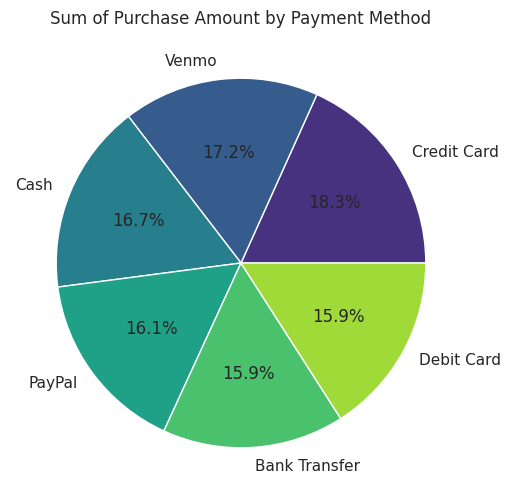

In [24]:
data.groupby("Payment Method")["Purchase Amount (USD)"].sum().sort_values(ascending=False).plot(
    kind="pie", autopct="%1.1f%%", ylabel=""
)
plt.title("Sum of Purchase Amount by Payment Method")
plt.show()

### 5.9 Discount Applied vs. Review Rating

In [25]:
data.groupby("Discount Applied")["Review Rating"].mean()

Discount Applied
No     3.757715
Yes    3.739654
Name: Review Rating, dtype: float64

Average review rating barely changes based on whether or not a discount was applied and discounting doesn't appear to buy extra customer satisfaction in this dataset.

### 5.10 Color Preferences by Category

In [26]:
data.groupby("Color")["Category"].value_counts()

Color   Category   
Beige   Clothing       65
        Accessories    44
        Footwear       24
        Outerwear      14
Black   Clothing       81
                       ..
White   Outerwear      15
Yellow  Clothing       75
        Accessories    56
        Footwear       30
        Outerwear      13
Name: count, Length: 100, dtype: int64

### 5.11 Purchase Frequency vs. Previous Purchases

In [27]:
data.groupby("Frequency of Purchases")["Previous Purchases"].median()

Frequency of Purchases
Annually          24.0
Bi-Weekly         24.0
Every 3 Months    24.0
Fortnightly       26.0
Monthly           25.0
Quarterly         28.0
Weekly            26.0
Name: Previous Purchases, dtype: float64

Median previous-purchase counts are similar regardless of stated shopping frequency, reinforcing that self-reported frequency doesn't line up neatly with actual historical purchase counts.

### 5.12 Review Rating by Season

In [28]:
data.groupby("Season")["Review Rating"].mean()

Season
Fall      3.729949
Spring    3.790591
Summer    3.725654
Winter    3.752111
Name: Review Rating, dtype: float64

### 5.13 Review Rating by Gender

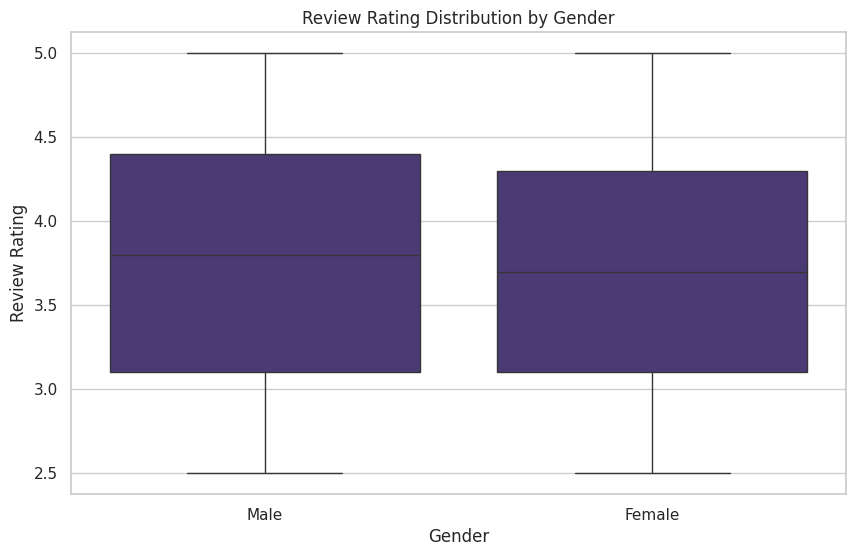

In [29]:
sns.boxplot(data=data, x="Gender", y="Review Rating")
plt.xlabel("Gender")
plt.ylabel("Review Rating")
plt.title("Review Rating Distribution by Gender")
plt.show()

Review rating distributions for Male and Female customers look almost identical in median and spread. It also shows that gender isn't a meaningful driver of satisfaction here.

### 5.14 Average Review Rating by Color

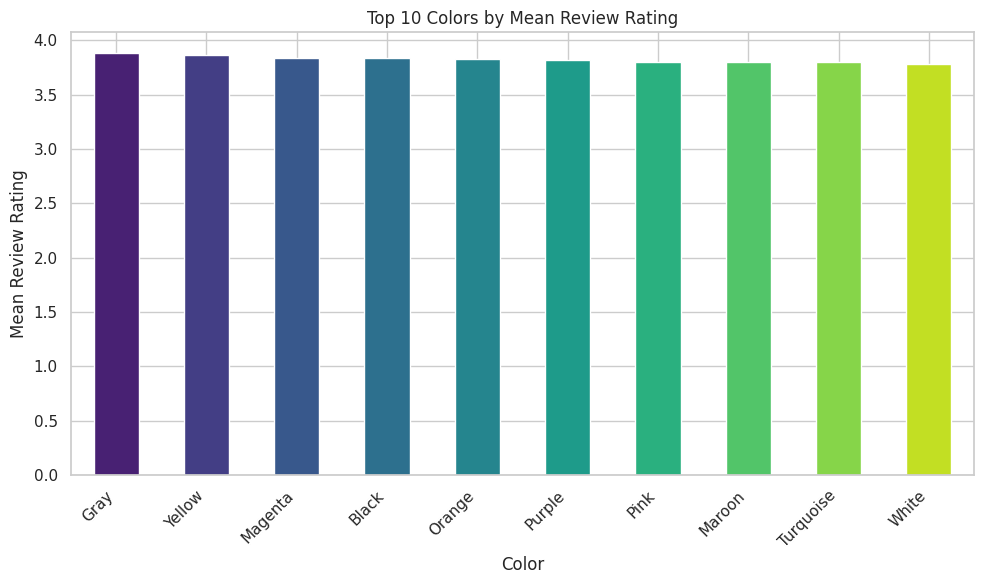

In [30]:
data.groupby("Color")["Review Rating"].mean().sort_values(ascending=False).head(10).plot(kind="bar", color=sns.color_palette("viridis", 10))
plt.xlabel("Color")
plt.ylabel("Mean Review Rating")
plt.title("Top 10 Colors by Mean Review Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.15 Total Purchase Amount by Season (Share of Revenue)

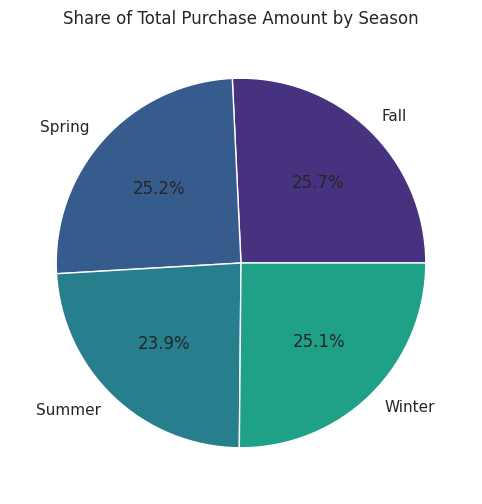

In [31]:
data.groupby("Season")["Purchase Amount (USD)"].sum().plot(kind="pie", autopct="%1.1f%%", ylabel="")
plt.title("Share of Total Purchase Amount by Season")
plt.show()

Revenue share across seasons mirrors the transaction-count split from Section 4.4. No season disproportionately drives total dollars, which lines up with purchase amount being independent of season.

## 6. Multivariate Analysis & Correlations

Extending the analysis to look at combinations of variables together, and quantifying relationships between the numeric fields directly.

### 6.1 Correlation Heatmap of Numeric Features

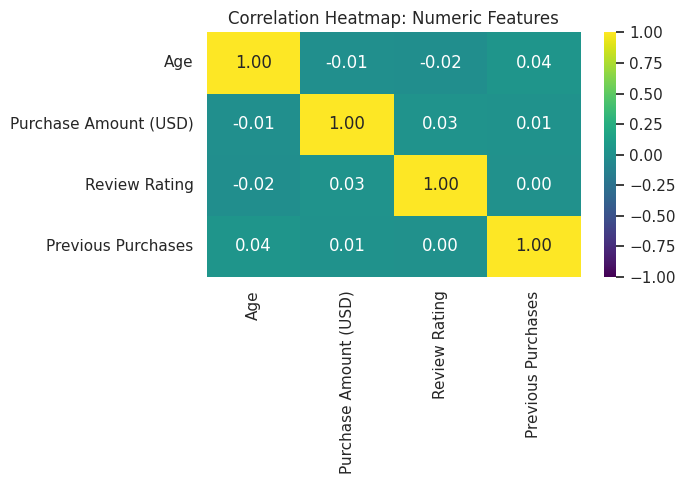

In [32]:
numeric_cols = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap: Numeric Features")
plt.tight_layout()
plt.show()

All pairwise correlations among Age, Purchase Amount, Review Rating, and Previous Purchases are close to zero. In other words, none of the numeric variables in this dataset linearly predict each other and spending, satisfaction, age, and purchase history are behaving as effectively independent signals.

### 6.2 Average Purchase Amount by Category and Gender

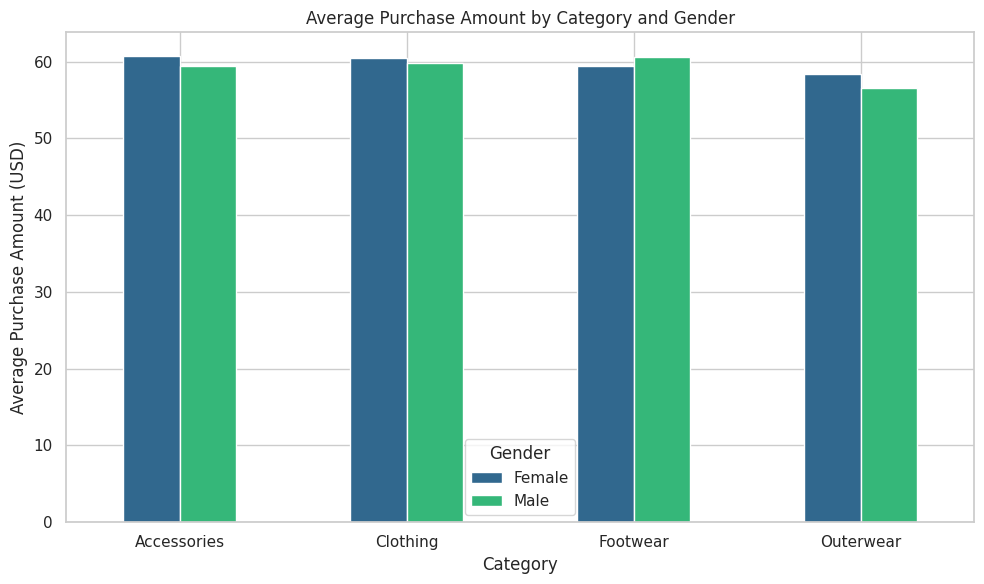

In [33]:
cat_gender = data.groupby(["Category", "Gender"])["Purchase Amount (USD)"].mean().unstack()
cat_gender.plot(kind="bar", figsize=(10, 6), color=sns.color_palette("viridis", 2))
plt.title("Average Purchase Amount by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

Even when splitting by both category and gender simultaneously, average spend stays tightly clustered. There's no combination of category and gender that stands out as a meaningfully higher or lower spending segment.

### 6.3 Subscription Status vs. Spending Behavior

In [34]:
sub_summary = data.groupby("Subscription Status").agg(
    avg_purchase_amount=("Purchase Amount (USD)", "mean"),
    avg_previous_purchases=("Previous Purchases", "mean"),
    avg_review_rating=("Review Rating", "mean"),
    customer_count=("Customer ID", "count"),
)
sub_summary

,avg_purchase_amount,avg_previous_purchases,avg_review_rating,customer_count
Subscription Status,,,,
No,59.865121,25.080436,3.752722,2847
Yes,59.491928,26.084520,3.742450,1053


Subscribers and non-subscribers spend almost the same amount per transaction and leave almost identical review ratings. The main difference is that non-subscribers make up the large majority of the customer base. Subscription status looks more like a segmentation flag than a driver of behavior.

### 6.4 Discount Applied vs. Purchase Amount

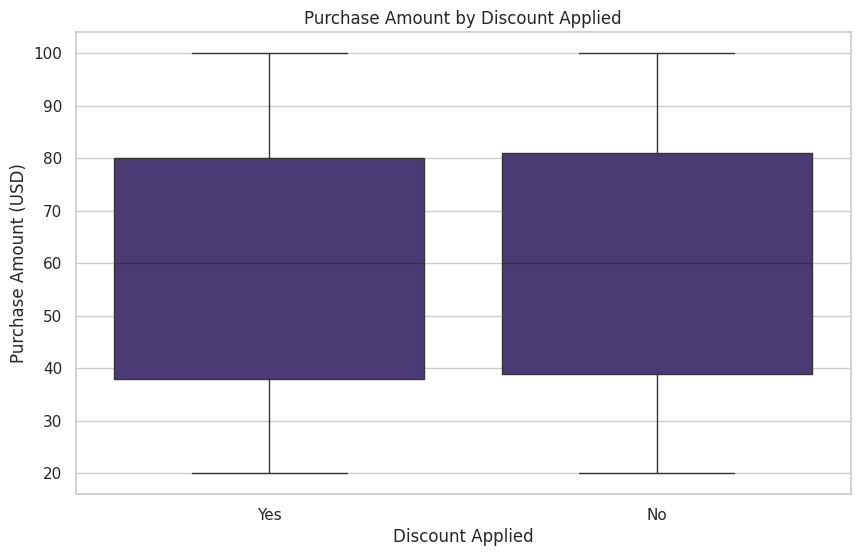

In [35]:
sns.boxplot(data=data, x="Discount Applied", y="Purchase Amount (USD)")
plt.title("Purchase Amount by Discount Applied")
plt.show()

Purchase amount distributions with and without a discount overlap almost completely and discounts in this dataset aren't associated with larger (or smaller) basket sizes.

### 6.5 Purchase Amount by Age Group

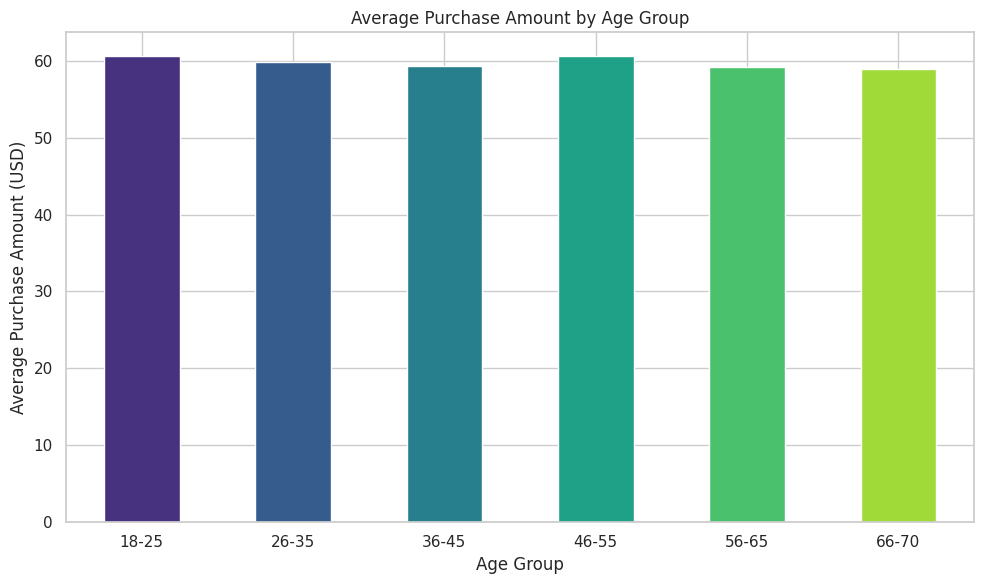

In [36]:
age_bins = [17, 25, 35, 45, 55, 65, 75]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66-70"]
data["Age Group"] = pd.cut(data["Age"], bins=age_bins, labels=age_labels)

data.groupby("Age Group", observed=True)["Purchase Amount (USD)"].mean().plot(
    kind="bar", color=sns.color_palette("viridis", 6)
)
plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average spend is remarkably flat across every age bracket from 18 to 70 and age is not a useful segmentation variable for predicting basket size in this dataset.

### 6.6 Top 10 Locations by Total Revenue

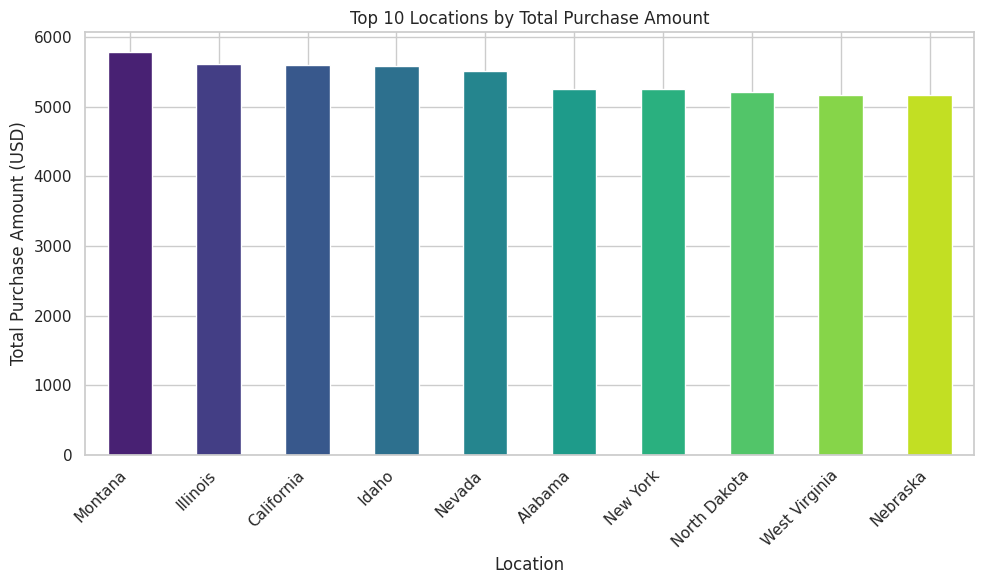

In [37]:
data.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar", color=sns.color_palette("viridis", 10)
)
plt.title("Top 10 Locations by Total Purchase Amount")
plt.xlabel("Location")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Revenue is spread broadly across states with no single location dominating. Consistent with the pattern seen throughout this dataset of flat, evenly distributed behavior across nearly every segment.

## 7. Key Insights & Takeaways

- **The dataset is clean:** no missing values and no duplicate rows, so results can be trusted without additional cleaning.
- **Clothing dominates category share**, followed by Accessories, Footwear, and Outerwear, but average spend *per transaction* is nearly identical across all four categories.
- **Demand is remarkably flat across nearly every dimension tested** and season, age group, gender, size, location, discount status, and subscription status all show very similar average purchase amounts and review ratings. This is a strong signal that purchase amount and review rating are driven by factors *not* captured in this dataset (e.g. the specific item, price point set by the retailer, or individual preference) rather than by demographic or behavioral segments.
- **Correlations between numeric variables (Age, Purchase Amount, Review Rating, Previous Purchases) are all close to zero**, confirming there's no simple linear relationship between customer history/demographics and how much they spend or how they rate their experience.
- **Only ~27% of customers are subscribers**, and subscribers don't spend more or rate higher than non-subscribers which suggests that the subscription program isn't currently tied to a measurable behavioral or spending benefit, which could be worth investigating from a business/marketing angle.
- **Payment methods and colors are both fairly evenly distributed**, with no single option overwhelmingly preferred, pointing to a customer base with diverse preferences rather than one converging on a "default" choice.